# **RANDOM FOREST (BASELINE)**

📥 1. Datos crudos importados.
🔄 2. Resampleando a 10Hz...
🔪 3. Split realizado. Train: 1543 | Val: 331 | Test: 331
🔥 4. Desplazando temperaturas a la línea base de 65 ºC...
🧬 5. Aplicando Data Augmentation en memoria (Solo a Train)...
🛠️ 6. Calculando características temporales (_rmean, _rstd, _lag)...

--- Generando Tablas Planas ---

🚀 Entrenando Random Forest...
✅ Entrenamiento de Random Forest finalizado en 0m 1s.
📊 Generando predicciones sobre el conjunto de Test...


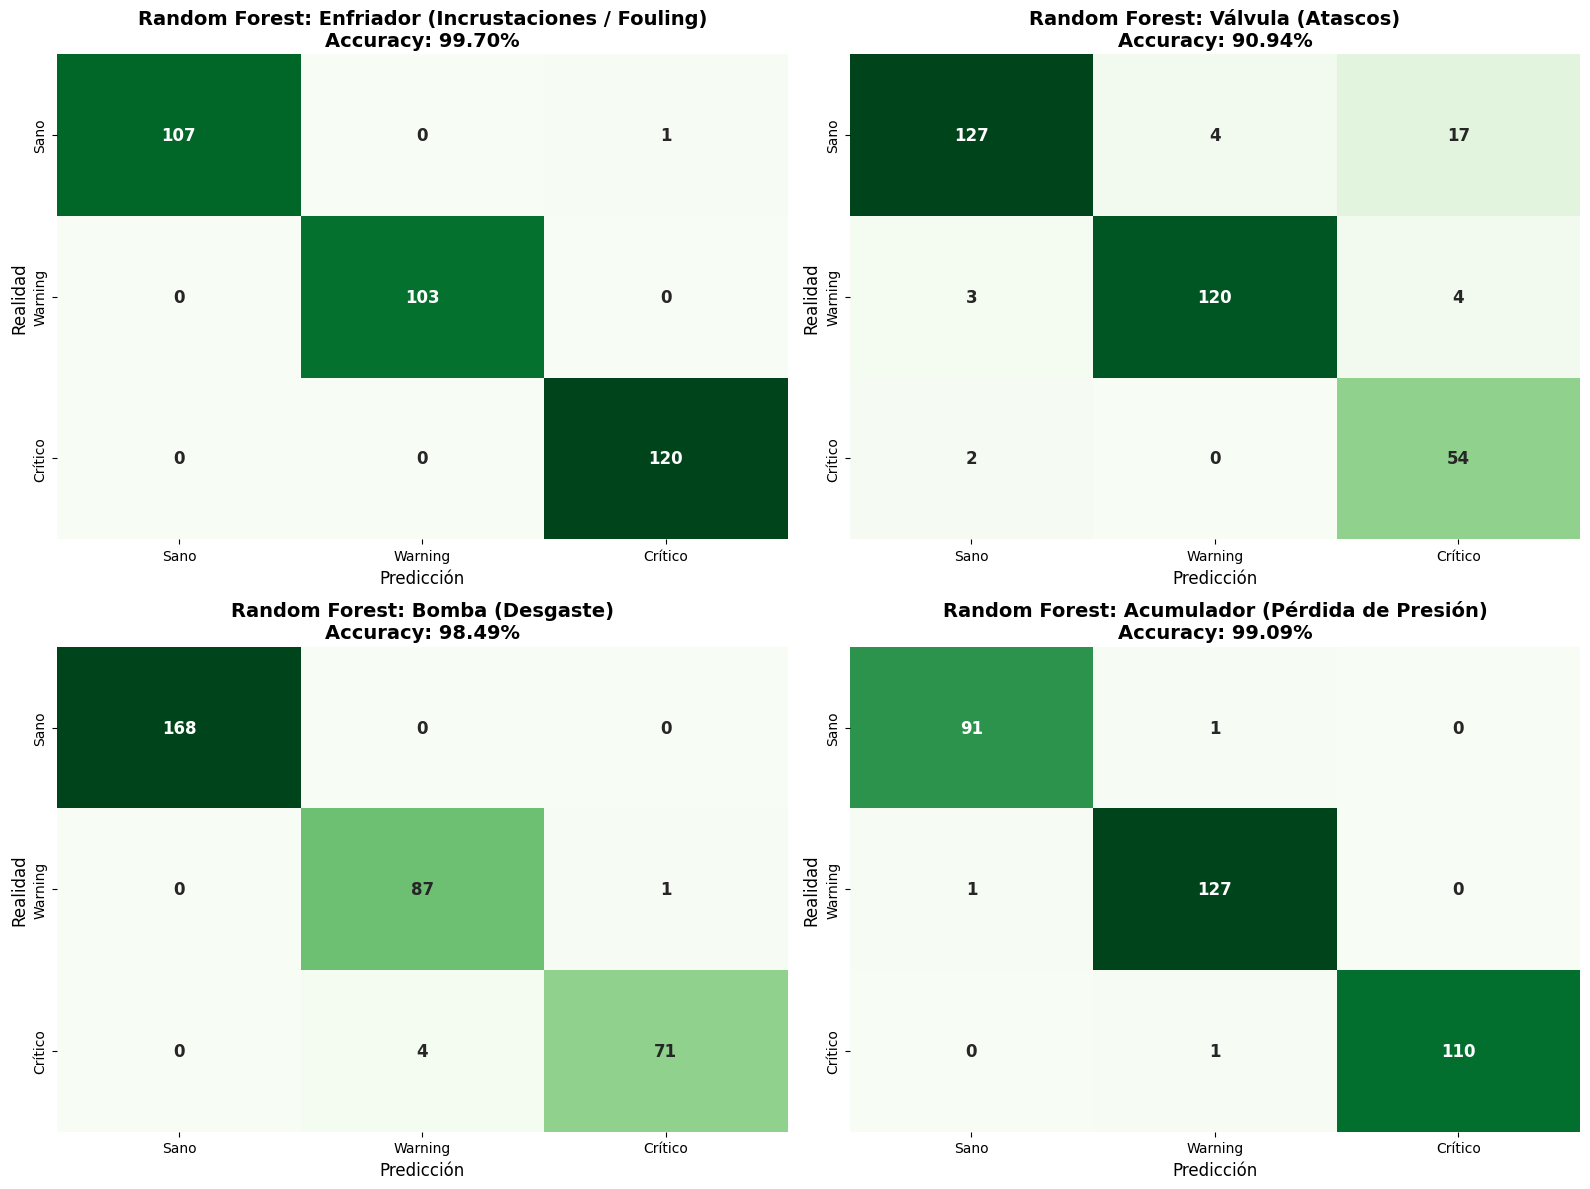


      📊 MÉTRICAS GLOBALES DEL MODELO RANDOM FOREST     
 🔹 Exactitud Global (Subset) :  0.8852
 🔹 Recall Global (Macro)     :  0.9721
 🔹 F1-Score Global (Macro)   :  0.9658



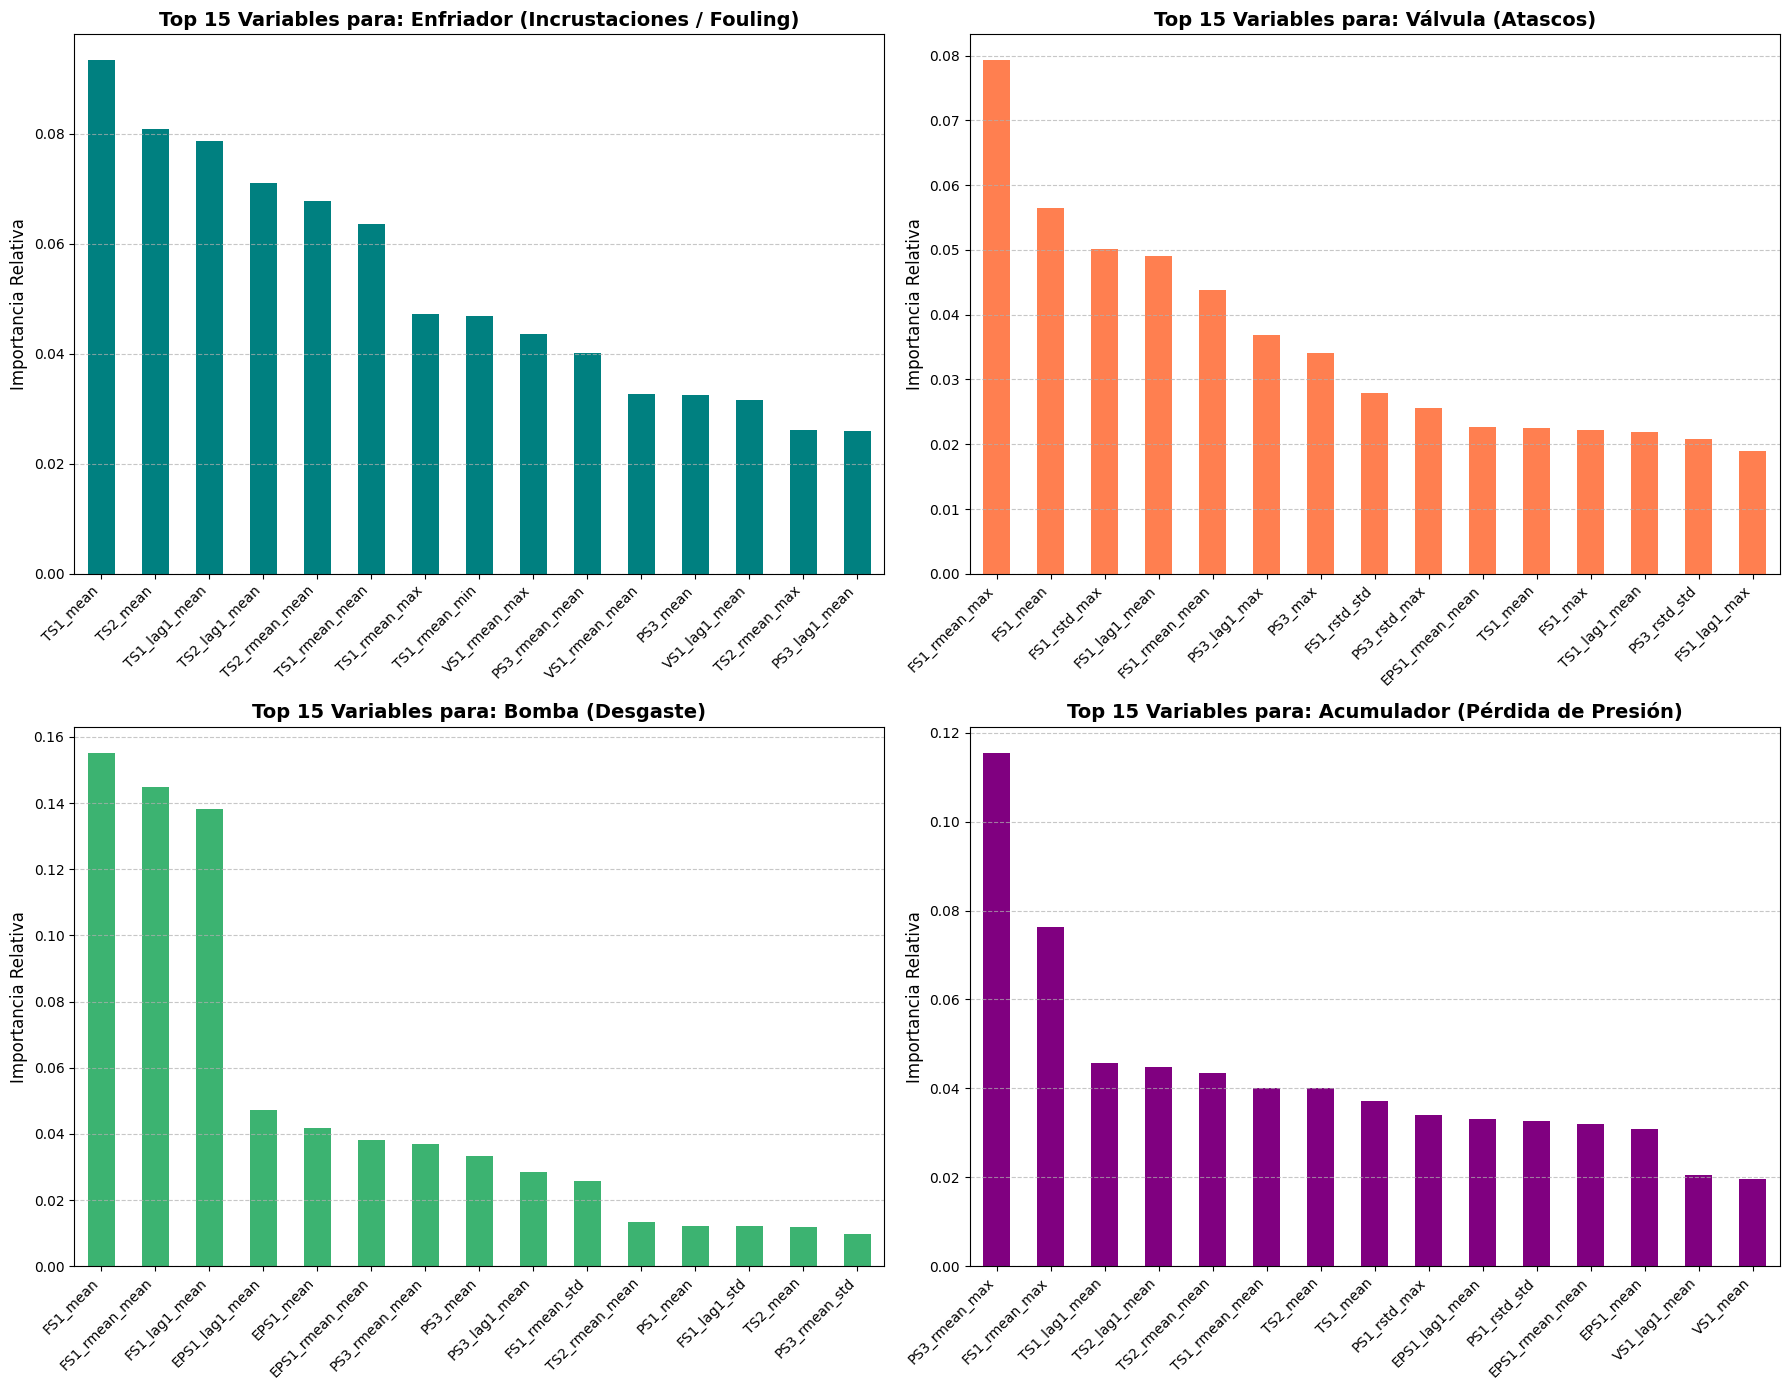

In [ ]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import random

# REPRODUCIBILIDAD
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
seed_everything()

# ==============================================================================
# 2. IMPORTACIÓN Y CONVERSIÓN DE ETIQUETAS
# ==============================================================================
df_raw = pd.read_csv("../../data/raw/hydraulic_raw.csv")
print("📥 1. Datos crudos importados.")

df_raw = df_raw.reset_index(drop=True)
df_raw['Time_Segundos'] = df_raw['Time'].round(1)

def map_cooler(val): return 0 if val == 100 else (1 if val == 20 else 2)
def map_valve(val): return 0 if val == 100 else (1 if val >= 80 else 2)
def map_pump(val): return 0 if val == 0 else (1 if val == 1 else 2)
def map_acc(val): return 0 if val == 130 else (1 if val >= 100 else 2)

df_raw['Target_Fouling'] = df_raw['Cooler_Condition'].apply(map_cooler)
df_raw['Target_Valvula'] = df_raw['Valve_Condition'].apply(map_valve)
df_raw['Target_Bomba'] = df_raw['Pump_Leakage'].apply(map_pump)
df_raw['Target_Acumulador'] = df_raw['Hydraulic_Accumulator'].apply(map_acc)

cols_targets = ['Target_Fouling', 'Target_Valvula', 'Target_Bomba', 'Target_Acumulador']
cols_sensores = ['PS1', 'PS3', 'EPS1', 'FS1', 'TS1', 'TS2', 'VS1']

# ==============================================================================
# 3. RESAMPLEO Y SPLIT TEMPRANO (Sin Leakage)
# ==============================================================================
print("🔄 2. Resampleando a 10Hz...")
df_grouped = df_raw.groupby(['Cycle_ID', 'Time_Segundos'])[cols_sensores].mean().reset_index()
df_targs = df_raw.groupby(['Cycle_ID'])[cols_targets].first().reset_index()   
df_10hz = pd.merge(df_grouped, df_targs, on='Cycle_ID')

unique_cycles = df_10hz['Cycle_ID'].unique()
train_cycles, temp_cycles = train_test_split(unique_cycles, test_size=0.30, random_state=42, shuffle=True)
val_cycles, test_cycles = train_test_split(temp_cycles, test_size=0.50, random_state=42, shuffle=True)

mask_train = df_10hz['Cycle_ID'].isin(train_cycles)
TS1_MEAN_TRAIN = df_10hz.loc[mask_train, 'TS1'].mean()
TS1_STD_TRAIN = df_10hz.loc[mask_train, 'TS1'].std()
print(f"🔪 3. Split realizado. Train: {len(train_cycles)} | Val: {len(val_cycles)} | Test: {len(test_cycles)}")

# 4. GESTIÓN DE LAS TEMPERATURAS:
# -----------------------------------------------------------
# En el dataset original las temperaturas distaban de 4ºC. Realizamos una traslacion para que disten de 65ºC (más parecido a un pasteurizador real):
print("🔥 4. Desplazando temperaturas a la línea base de 65 ºC...")
df_thermo = df_10hz.copy()

# Calculamos la diferencia entre la media original del dataset y el nuevo objetivo (65 ºC)
offset_temperatura = 65.0 - TS1_MEAN_TRAIN

# Aplicamos el desplazamiento a los sensores de temperatura
df_thermo['TS1'] = df_thermo['TS1'] + offset_temperatura
df_thermo['TS2'] = df_thermo['TS2'] + offset_temperatura

# ==============================================================================
# 5. DATA AUGMENTATION (Ruido solo a los sensores de Train)
# ==============================================================================
print("🧬 5. Aplicando Data Augmentation en memoria (Solo a Train)...")
df_train_only = df_thermo[df_thermo['Cycle_ID'].isin(train_cycles)].copy()
df_noisy = df_train_only.copy()
df_noisy['Cycle_ID'] = df_noisy['Cycle_ID'] + 50000 

noise_level = 0.40
for c_name in cols_sensores:
    std_dev = df_noisy[c_name].std()
    noise = np.random.normal(0, std_dev * noise_level, size=len(df_noisy))
    df_noisy[c_name] += noise

df_aug = pd.concat([df_thermo, df_noisy], ignore_index=True)
train_cycles_aug = np.concatenate([train_cycles, df_noisy['Cycle_ID'].unique()])

# ==============================================================================
# 6. FEATURE ENGINEERING (Medias y Lags para TODOS los ciclos combinados)
# ==============================================================================
print("🛠️ 6. Calculando características temporales (_rmean, _rstd, _lag)...")
def engineer_features(group):
    group = group.sort_values('Time_Segundos') 
    X = group[cols_sensores]                    
    rmean = X.rolling(5, min_periods=1).mean().add_suffix('_rmean')
    rstd = X.rolling(5, min_periods=1).std().fillna(0).add_suffix('_rstd')
    lag = X.shift(1).bfill().add_suffix('_lag1') 
    return pd.concat([group, rmean, rstd, lag], axis=1)

df_final = df_aug.groupby('Cycle_ID', group_keys=False).apply(engineer_features).reset_index(drop=True)

# Reordenamos columnas
cols_nuevas = [c for c in df_final.columns if '_rmean' in c or '_rstd' in c or '_lag1' in c]
cols_ordenadas = ['Cycle_ID', 'Time_Segundos'] + cols_sensores + cols_nuevas + cols_targets
df_final = df_final[cols_ordenadas]

# ==============================================================================
# 7. APLANAMIENTO PARA RANDOM FOREST
# ==============================================================================
def flatten_time_series_for_ml(df_input, feature_columns, target_columns):
    X = df_input.groupby('Cycle_ID')[feature_columns].agg(['mean', 'std', 'min', 'max'])
    X.columns = ['_'.join(col) for col in X.columns]
    y = df_input.groupby('Cycle_ID')[target_columns].first()
    return X, y

# Definimos claramente las columnas para que no lance NameError
targets_finales = cols_targets
feature_cols = [c for c in df_final.columns if c not in ['Cycle_ID', 'Time_Segundos', 'date'] + targets_finales]

print("\n--- Generando Tablas Planas ---")
X_train, y_train = flatten_time_series_for_ml(df_final[df_final['Cycle_ID'].isin(train_cycles_aug)], feature_cols, targets_finales)
X_val, y_val = flatten_time_series_for_ml(df_final[df_final['Cycle_ID'].isin(val_cycles)], feature_cols, targets_finales)
X_test, y_test = flatten_time_series_for_ml(df_final[df_final['Cycle_ID'].isin(test_cycles)], feature_cols, targets_finales)

# ==============================================================================
# 8. ENTRENAMIENTO DEL MODELO RF BASELINE
# ==============================================================================
rf_pipeline = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf = 5, random_state=42, n_jobs=-1, class_weight='balanced')
)

rf_base = MultiOutputClassifier(rf_pipeline, n_jobs=-1)

print("\n🚀 Entrenando Random Forest...")
start_time = time.time() 
rf_base.fit(X_train, y_train)
end_time = time.time() 
mins = int((end_time - start_time) // 60)
secs = int((end_time - start_time) % 60)
print(f"✅ Entrenamiento de Random Forest finalizado en {mins}m {secs}s.")

# ==============================================================================
# 9. EVALUACIÓN Y MATRICES DE CONFUSIÓN
# ==============================================================================
print("📊 Generando predicciones sobre el conjunto de Test...")
y_pred = rf_base.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=y_test.columns, index=y_test.index)

class_names = ['Sano', 'Warning', 'Crítico']
target_names = ['Enfriador (Incrustaciones / Fouling)', 'Válvula (Atascos)', 'Bomba (Desgaste)', 'Acumulador (Pérdida de Presión)']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, target in enumerate(targets_finales):
    cm = confusion_matrix(y_test[target], y_pred_df[target])
    acc = accuracy_score(y_test[target], y_pred_df[target])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, cbar=False,
                annot_kws={"size": 12, "weight": "bold"})
    
    axes[i].set_title(f'Random Forest: {target_names[i]}\nAccuracy: {acc:.2%}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Realidad', fontsize=12)
    axes[i].set_xlabel('Predicción', fontsize=12)

plt.tight_layout()
plt.show()

# ==============================================================================
# 10. MÉTRICAS GLOBALES RIGUROSAS
# ==============================================================================
subset_accuracy_rf = (y_test == y_pred_df).all(axis=1).mean()
recalls_macro_rf, f1s_macro_rf = [], []

for target in targets_finales:
    recalls_macro_rf.append(recall_score(y_test[target], y_pred_df[target], average='macro', zero_division=0))
    f1s_macro_rf.append(f1_score(y_test[target], y_pred_df[target], average='macro', zero_division=0))

global_macro_recall_rf = np.mean(recalls_macro_rf)
global_macro_f1_rf = np.mean(f1s_macro_rf)

print("\n" + "="*55)
print(" 📊 MÉTRICAS GLOBALES DEL MODELO RANDOM FOREST ".center(55))
print("="*55)
print(f" 🔹 Exactitud Global (Subset) :  {subset_accuracy_rf:.4f}")
print(f" 🔹 Recall Global (Macro)     :  {global_macro_recall_rf:.4f}")
print(f" 🔹 F1-Score Global (Macro)   :  {global_macro_f1_rf:.4f}")
print("="*55 + "\n")

# ==============================================================================
# 11. ANÁLISIS DE IMPORTANCIA DE VARIABLES POR COMPONENTE (FEATURE IMPORTANCE)
# ==============================================================================
nombres_features = X_train.columns
target_names = ['Enfriador (Incrustaciones / Fouling)', 'Válvula (Atascos)', 'Bomba (Desgaste)', 'Acumulador (Pérdida de Presión)']

# Colores para diferenciar cada gráfica
colores = ['teal', 'coral', 'mediumseagreen', 'purple']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# Iteramos sobre los 4 pipelines internos del MultiOutputClassifier
for i, target in enumerate(target_names):
    # Sacamos el modelo Random Forest específico para el target 'i'
    rf_model = rf_base.estimators_[i].named_steps['randomforestclassifier']
    importancias = rf_model.feature_importances_
    
    # Creamos la Serie y sacamos el Top 15 para que sea legible
    serie_importancias = pd.Series(importancias, index=nombres_features).sort_values(ascending=False).head(15)
    
    # Ploteamos en su cuadrícula correspondiente
    serie_importancias.plot(kind='bar', color=colores[i], ax=axes[i])
    
    axes[i].set_title(f'Top 15 Variables para: {target}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Importancia Relativa', fontsize=12)
    
    # Rotar las etiquetas para que no se pisen
    axes[i].set_xticklabels(serie_importancias.index, rotation=45, ha='right', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ==============================================================================
# 12. GUARDADO DEL MODELO
# ==============================================================================
# ruta_modelos = "../../models/artifacts/"
# os.makedirs(ruta_modelos, exist_ok=True)
# 
# joblib.dump(rf_base, os.path.join(ruta_modelos, "random_forest_baseline.pkl"))
# joblib.dump(X_train.columns.tolist(), os.path.join(ruta_modelos, "rf_flattened_features.pkl"))
# print(f"💾 Modelo Random Forest guardado en {ruta_modelos}")